### Corrective RAG

Corrective RAG (CRAG) is an advanced technique with in Retrieval-Augmented Generation (RAG) that focuses on improving the accuracy and relevance of generated responses by incorporating mechanisms for self-reflection and self-grading for retrieved documents. It does this by evaluating the quality of retrieved documents and applying corrective actions when necessary, such as refining or replacing incorrect retrievals.

#### Addressing Limitations of Basic RAG:
Traditional RAG systems rely heavily on the accuracy of retrieved documents. If the retrieved information is flawed or incomplete, the generated response can also be inaccurate.

#### CRAG's Core Components:
1. `Retrieval Evauator`: This component assesses the quality and relevance of retrieved docments.
2. `Generative Model`: This model generates the initial response based on the retrieved information.
3. `Refinement and Correction`: CRAG employs strategies like knowledge refinement or web search to address issues identified by the retrieval evaluator.

#### Benefits of CRAG:
1. `Improved Accuracy`: By evaluating and correcting retrieved information, CRAG helps ensure the accuracy of generated responses.
2. `Enhanced Relevance`: CRAG can identify and filter out irrelevant information, making the generated response more relevant.
3. `Increased Robustness`: CRAG can handle cases where the initial retrieval process is not perfect, leading to a more robust RAG system.

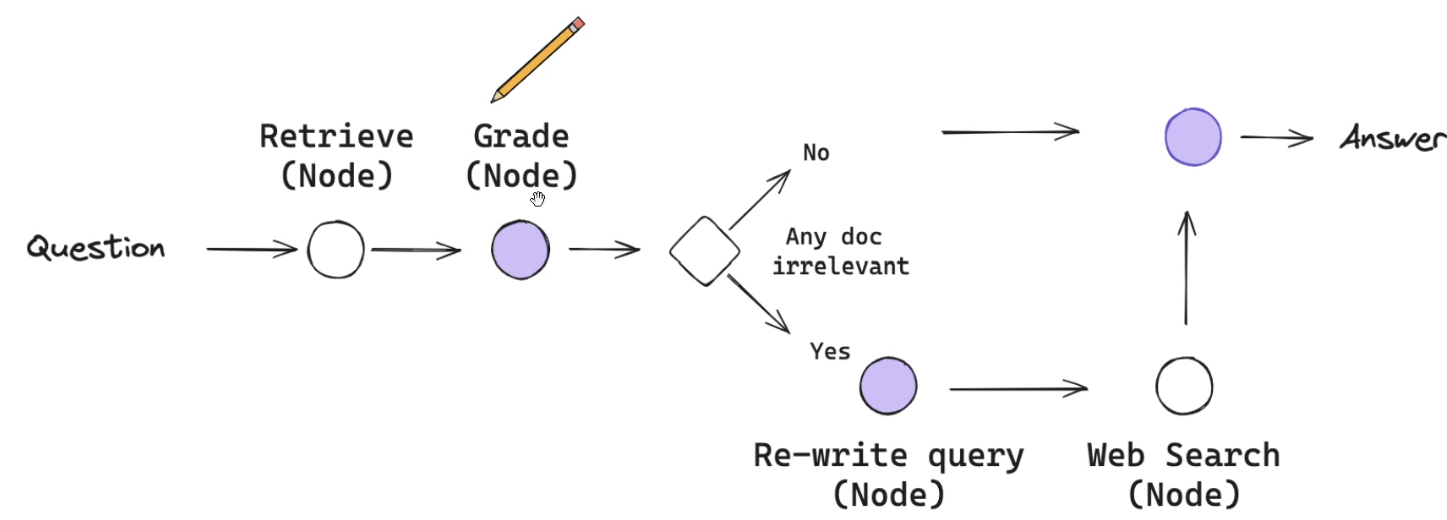

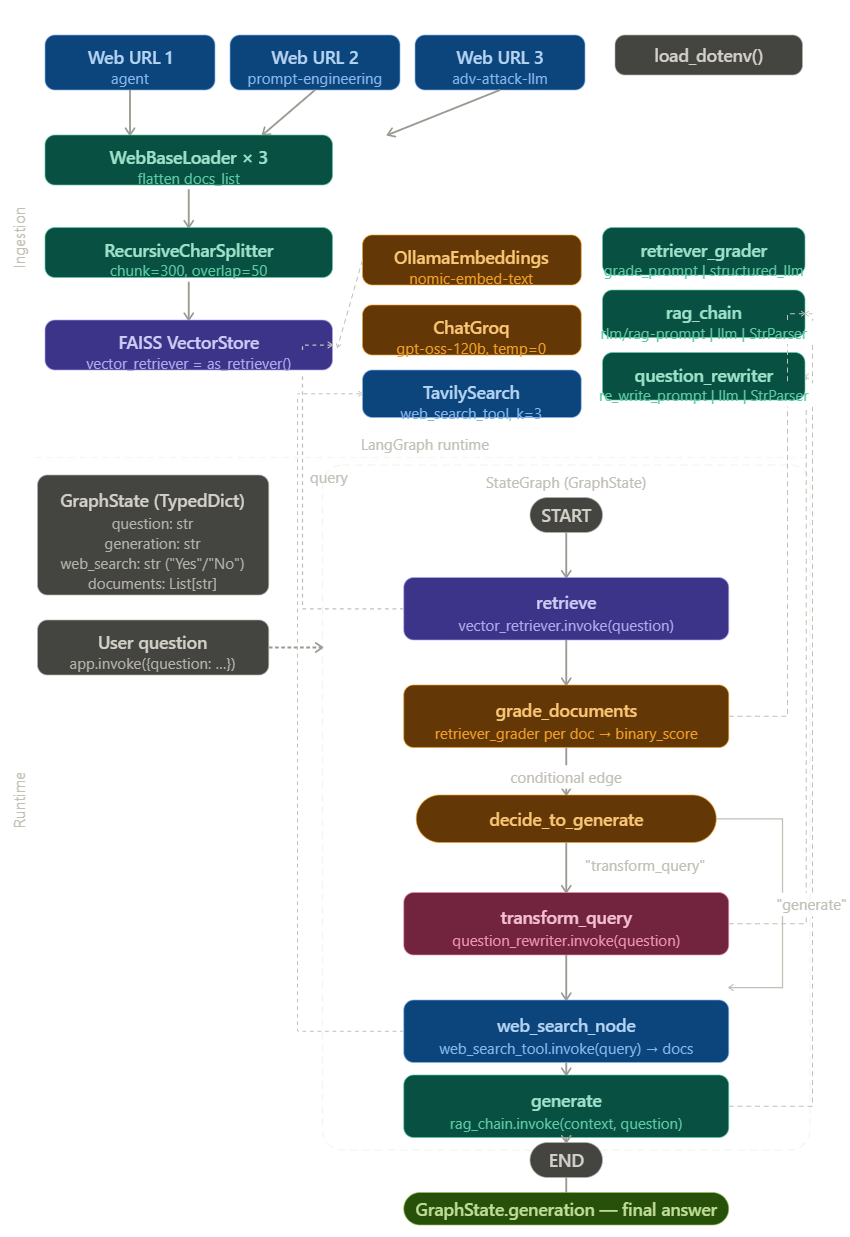

In [2]:
# ------------------------------------------------------------
# 1. Web Document, Vector DB, LLM and Embeddings 
# ------------------------------------------------------------

from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_ollama.embeddings import OllamaEmbeddings
import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')
os.environ['TAVILY_API_KEY'] = os.getenv('tavily_api_key')

# Url
urls = [
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/',
    'https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/'
]

# Web Loader
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Splitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
doc_split = text_splitter.split_documents(docs_list)

embedding = OllamaEmbeddings(model='nomic-embed-text')

# Vector Store
vector_db = FAISS.from_documents(doc_split, embedding)
vector_retriever = vector_db.as_retriever()

### 1. Retriever Grader

In [4]:
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate

# Data Model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""
    
    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

# LLM with function call
llm = ChatGroq(model='openai/gpt-oss-120b', max_tokens=1000, temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question. \n
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
    
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system),
        ('human', 'Retrieved document:\n\n{document}\n\nUser Question: {question}')
    ]
)

# Chain
retriever_grader = grade_prompt | structured_llm_grader

# Test
question = 'agent memory'
docs = vector_retriever.invoke(question)

doc_txt = docs[1].page_content
print(retriever_grader.invoke({'question': question, 'document': doc_txt}))

binary_score='yes'


### 2. Generate

In [5]:
from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser

# Prompt
prompt = hub.pull('rlm/rag-prompt')

# Post-Preprocessing
def format_docs(docs):
    return '\n\n'.join(doc.page_content for doc in docs)

# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke({'context': docs, 'question': question})

print(generation)

In LLM‑powered autonomous agents, short‑term memory is the in‑context learning that lets the model use the current prompt as a temporary store. Long‑term memory is an external vector store that the agent can query quickly, enabling it to retain and recall virtually unlimited information over time. This combination lets the agent remember past interactions while still accessing a persistent knowledge base.


### 3. Question Re-Writer

In [6]:
# Prompt
system = """You can re-write the question that converts an input question to a better version that is optimized \n
    for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""
    
re_write_prompt = ChatPromptTemplate(
    [
        ('system', system),
        ('human', 'Here is the initial question:\n\n{question} \n Formulate an improved question.')
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
result = question_rewriter.invoke({'question': question})
print(result)

**Improved search‑friendly question**

*What is “agent memory” in artificial intelligence, and how do different memory architectures (e.g., short‑term, long‑term, episodic, and working memory) affect the behavior and performance of autonomous AI agents?*


### 4. Web Search - Tavily

In [7]:
from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(k=3)

In [8]:
from typing import TypedDict, List

class GraphState(TypedDict):
    """
    Represents the state of our graph.
    
    Attributes:
        question: question
        generation: LLM generation
        web_search: Whether to add search
        documents: list of documents
    """
    question: str
    generation: str
    web_search: str
    documents: List[str]

In [9]:
from langchain_classic.schema import Document

def retrieve(state: GraphState) -> GraphState:
    """
    Retrieve documents
    
    Args:
        state (dict): The current graph state
        
    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print('------- Retrieve -------')
    question = state['question']
    
    # Retrieval
    documents = vector_retriever.invoke(question)
    
    return {'documents': documents, 'question': question}

def generate(state: GraphState) -> GraphState:
    """
    Generate answer
    
    Args:
        state (dict): The current graph state
        
    Return:
        state (dict): New key add to state, generation, that contains LLM generation
    """
    print('------- Generate -------')
    question = state['question']
    documents = state['documents']
    
    # RAG Generation
    generation = rag_chain.invoke({'context': documents, 'question': question})
    
    return {'documents': documents, 'question': question, 'generation': generation}

def grade_documents(state: GraphState) -> GraphState:
    """
    Determines whether the retrieved documents are relevant to the question.
    
    Args:
        state (dict): The current graph state
        
    Return:
        state (dict): Updates documents key with only filtered relevant documents
    """
    print('------- Check Document Relevant to Question -------')
    question = state['question']
    documents = state['documents']
    
    # Score each doc
    filtered_doc = []
    web_search = 'No'
    
    for d in documents:
        score = retriever_grader.invoke(
            {'question': question, 'document': d.page_content}
        )
        grade = score.binary_score
        if grade == 'yes':
            print('------- Grade: Document Relevant -------')
            filtered_doc.append(d)
        else:
            print('------- Grade: Document Not Relevant -------')
            web_search = 'Yes'
            continue
    return {'documents': filtered_doc, 'question': question, 'web_search': web_search}

def transform_query(state: GraphState) -> GraphState:
    """
    Transform the query to produce a better question.
    
    Args:
        state (dict): The current graph state
        
    Return:
        state (dict): Updates question key with a re-phrased question
    """
    print('------- Transform Query -------')
    question = state['question']
    documents = state['documents']
    
    # Re-Write question
    better_question = question_rewriter.invoke({'question': question})
    return {'documents': documents, 'question': better_question}

def web_search(state: GraphState) -> GraphState:
    """
    Web search based on the re-phrased question.
    
    Args:
        state (dict): The current graph state
        
    Return:
        state (dict): Updates documents key with appended web result
    """
    print('------- Web Search -------')
    question = state['question']
    documents = state['documents']
    
    # Web search
    docs = web_search_tool.invoke({'query': question})
    web_results = '\n\n'.join([d['content'] for d in docs])
    web_results = Document(page_content=web_results)
    documents.append(web_results)
    
    return {'documents': documents, 'question': question}

# Edges

def decide_to_generate(state: GraphState) -> GraphState:
    """
    Determines whether to generate an answer or re-generate a question.
    
    Args:
        state (dict): The current graph state
        
    Return:
        str: Binary decision for next node to call
    """
    print('------- Assess Graded Documents -------')
    state['question']
    web_search = state['web_search']
    state['documents']
    
    if web_search == 'yes':
        # All documents have been filtered check_relevance
        # Will re-generate a new query
        print('------- Decision: All documents are not relevant to question, transform query -------')
        return 'transform_query'
    else:
        # Relevant documents, so generate answer
        print('------- Decision: Generate -------')
        return 'generate'

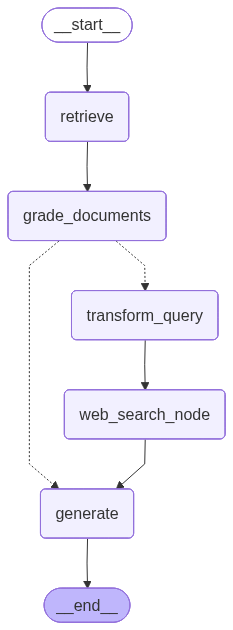

In [10]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(GraphState)

# Define the Nodes
workflow.add_node('retrieve', retrieve) # retrieve
workflow.add_node('grade_documents', grade_documents) # grade_documents
workflow.add_node('generate', generate) # generate
workflow.add_node('transform_query', transform_query) # transform_query
workflow.add_node('web_search_node', web_search) # Web search

# Build graph
workflow.add_edge(START, 'retrieve')
workflow.add_edge('retrieve', 'grade_documents')
workflow.add_conditional_edges(
    'grade_documents',
    decide_to_generate,
    {
        'transform_query': 'transform_query',
        'generate': 'generate'
    }
)
workflow.add_edge('transform_query', 'web_search_node')
workflow.add_edge('web_search_node', 'generate')
workflow.add_edge('generate', END)

# Compile
app = workflow.compile()
app

In [11]:
app.invoke({'question': 'what are the types of agent memory?'})

------- Retrieve -------
------- Check Document Relevant to Question -------
------- Grade: Document Relevant -------
------- Grade: Document Relevant -------
------- Grade: Document Relevant -------
------- Grade: Document Not Relevant -------
------- Assess Graded Documents -------
------- Decision: Generate -------
------- Generate -------


{'question': 'what are the types of agent memory?',
 'generation': 'Agent memory is typically divided into two categories: **short‑term memory**, which uses the model’s in‑context learning to retain recent information during a session, and **long‑term memory**, which stores knowledge persistently (often in an external vector store) for retrieval across sessions. Some frameworks also mention **implicit/procedural memory**, representing unconscious skills or routines. These types together enable agents to both reason on the fly and recall past experiences.',
 'web_search': 'Yes',
 'documents': [Document(id='58740a0d-7deb-43ca-ac25-457c6854c4de', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The poten